In [1]:
import os
# Quick backup utility for ephemeral storage
if os.path.exists('/content/models'):
    !zip -q -r /content/artefacts.zip models figures data/metadata_split.csv
    print("Artefacts zipped. Download using the file explorer or files.download() if needed.")

In [2]:
from google.colab import files

if os.path.exists('/content/artefacts.zip'):
    files.download('/content/artefacts.zip')
else:
    print("File not found. Please ensure the backup cell at the top has run successfully.")

File not found. Please ensure the backup cell at the top has run successfully.


In [3]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


# Skin Lesion Classification — HAM10000Binary malignant vs. benign classification on the HAM10000 dermatoscopic image set.**Methodological continuity with the tabular summative:** this project transfers the samediscipline — cost-sensitive learning under class imbalance, rank-based metrics (ROC-AUC,PR-AUC) in preference to accuracy, and explicit threshold selection — to a non-tabularmodality. Minority (malignant) prevalence here is ~19.5%, close to the 22.1% default ratein the tabular study, so the imbalance treatment carries over almost unchanged.Run top to bottom. Cells 2-3 only need to run once.

## 1. Configuration

In [4]:
import os
import json
import random
import shutil
import pathlib
import time
import numpy as np
import pandas as pd

SEED       = 42
IMG_SIZE   = 128          # a native MobileNetV2 pretrained resolution
BATCH_SIZE = 32

# melanoma, basal cell carcinoma, actinic keratosis
MALIGNANT  = {"mel", "bcc", "akiec"}
BENIGN     = {"nv", "bkl", "vasc", "df"}

ROOT      = pathlib.Path(".").resolve()
DATA_DIR  = ROOT / "data"
RAW_DIR   = DATA_DIR / "raw"
IMAGES_DIR= RAW_DIR / "images"
CACHE_DIR = DATA_DIR / "cache"
MODEL_DIR = ROOT / "models"
FIG_DIR   = ROOT / "figures"

for d in (RAW_DIR, CACHE_DIR, MODEL_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("root:", ROOT)

root: /content


## 2. Data acquisitionNeeds `~/.kaggle/kaggle.json` (Kaggle → Settings → API → Create New Token), then`chmod 600 ~/.kaggle/kaggle.json`.Only the two image archives and the metadata CSV matter. The mirror also ships`hmnist_*.csv` files containing pre-flattened pixels — **do not use those**, they would turnthis back into a tabular problem.

In [5]:
# 1. Ensure Kaggle credentials are set up
!mkdir -p ~/.kaggle
!cp -f /content/kaggle.json ~/.kaggle/ 2>/dev/null || echo "Warning: kaggle.json not found in /content"
!chmod 600 ~/.kaggle/kaggle.json

# 2. Download and Unzip with forced overwrite to ensure clean state
print("Downloading dataset...")
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p {RAW_DIR} --unzip

# 3. Verify files exist
print("\nFiles in RAW_DIR:")
!ls {RAW_DIR}

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:37<00:00, 151MB/s] 


Files in RAW_DIR:
ham10000_images_part_1	HAM10000_images_part_2	hmnist_28_28_RGB.csv
HAM10000_images_part_1	HAM10000_metadata.csv	hmnist_8_8_L.csv
ham10000_images_part_2	hmnist_28_28_L.csv	hmnist_8_8_RGB.csv


In [6]:
# Merge the two image folders into one flat directory.
IMAGES_DIR.mkdir(exist_ok=True)

for part in ("HAM10000_images_part_1", "HAM10000_images_part_2",
             "ham10000_images_part_1", "ham10000_images_part_2", "HAM10000_images"):
    src = RAW_DIR / part
    if src.exists() and src.is_dir():
        for p in src.glob("*.jpg"):
            shutil.move(str(p), str(IMAGES_DIR / p.name))
        print("merged", part)

n_imgs = len(list(IMAGES_DIR.glob("*.jpg")))
print(f"{n_imgs} images in {IMAGES_DIR}")
assert n_imgs == 10015, "Expected 10015 images - check the archive extracted fully."

merged HAM10000_images_part_1
merged HAM10000_images_part_2
merged ham10000_images_part_1
merged ham10000_images_part_2
10015 images in /content/data/raw/images


## 3. Metadata, labels, and data-quality checks

In [7]:
import os
import pandas as pd

# Flexible search for the metadata file
matches = list(RAW_DIR.rglob("HAM10000_metadata.csv"))
if not matches:
    matches = list(RAW_DIR.rglob("*.csv")) # Fallback to any CSV

if not matches:
    print(f"Error: No CSV found in {RAW_DIR}")
    raise FileNotFoundError("Dataset metadata not found. Please re-run the download cell.")

meta_path = matches[0]
meta = pd.read_csv(meta_path)
print(f"Loaded metadata from: {meta_path}")
print(f"Shape: {meta.shape}")
meta.head()

Loaded metadata from: /content/data/raw/HAM10000_metadata.csv
Shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [8]:
# Binary target: 1 = malignant / pre-malignant, 0 = benign
assert set(meta["dx"].unique()) == MALIGNANT | BENIGN

meta["label"] = meta["dx"].isin(MALIGNANT).astype(int)
print(meta["dx"].value_counts(), "\n")

counts = meta["label"].value_counts().sort_index()
prev = counts[1] / counts.sum()

print(f"benign {counts[0]}  malignant {counts[1]}")
print(f"malignant prevalence: {prev:.3%}   imbalance ratio {counts[0]/counts[1]:.2f} : 1")

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64 

benign 8061  malignant 1954
malignant prevalence: 19.511%   imbalance ratio 4.13 : 1


In [9]:
# --- Data-quality checks ---
print("missing values per column:")
print(meta.isna().sum())

# age has a small number of NaNs; median-impute for the EDA only
meta["age"] = meta["age"].fillna(meta["age"].median())

# HAM10000 contains MULTIPLE IMAGES OF THE SAME LESION.
per_lesion = meta.groupby("lesion_id").size()
print(f"\nunique lesions: {meta['lesion_id'].nunique()} for {len(meta)} images")
print("images per lesion:\n", per_lesion.value_counts().sort_index())

# A lesion must have a single consistent diagnosis
assert meta.groupby("lesion_id")["label"].nunique().max() == 1

# Every metadata row must have a file on disk.
meta["path"] = meta["image_id"].apply(lambda i: str(IMAGES_DIR / f"{i}.jpg"))
missing = [p for p in meta["path"] if not os.path.exists(p)]
print("missing image files:", len(missing))
assert not missing

missing values per column:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
label            0
dtype: int64

unique lesions: 7470 for 10015 images
images per lesion:
 1    5514
2    1423
3     490
4      34
5       5
6       4
Name: count, dtype: int64
missing image files: 0


### Why the duplicate-lesion finding mattersRoughly 25% of the rows are repeat photographs of a lesion already present elsewhere in thetable. A naive random split by *image* would put the same physical mole in both train andtest, and the reported AUC would be inflated by leakage rather than by learning. The split insection 6 is therefore performed at the `lesion_id` level. This is the same leakage disciplineapplied in the tabular study when preprocessing was fit on the training partition only.

## 4. Exploratory analysis — three feature interpretations

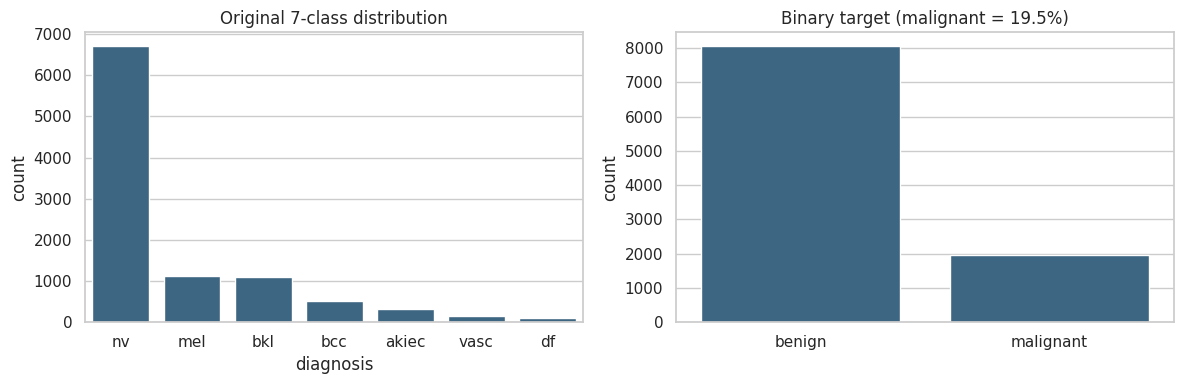

In [10]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=meta, x="dx", order=meta["dx"].value_counts().index, ax=ax[0], color="#31688e")
ax[0].set_title("Original 7-class distribution")
ax[0].set_xlabel("diagnosis")

sns.countplot(data=meta, x="label", ax=ax[1], color="#31688e")
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(["benign", "malignant"])
ax[1].set_title(f"Binary target (malignant = {prev:.1%})")
ax[1].set_xlabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_class_distribution.png", dpi=150)
plt.show()

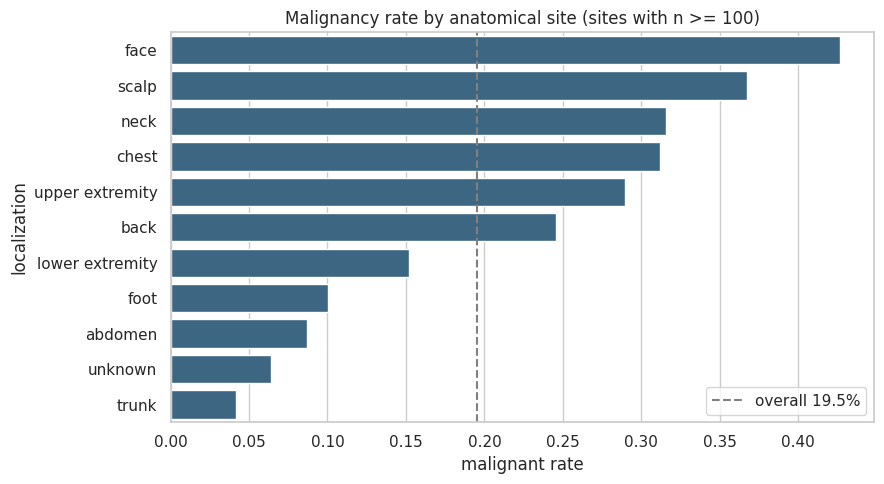

,n,malignant_rate
localization,,
face,745,0.426846
scalp,128,0.367188
neck,168,0.315476
chest,407,0.312039
upper extremity,1118,0.289803
back,2192,0.245894
lower extremity,2077,0.151661
foot,319,0.100313
abdomen,1022,0.087084


In [11]:
# --- Interpretation 1: anatomical site ---
loc = (meta.groupby("localization")
            .agg(n=("label", "size"), malignant_rate=("label", "mean"))
            .query("n >= 100")
            .sort_values("malignant_rate", ascending=False))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=loc.reset_index(), y="localization", x="malignant_rate", ax=ax, color="#31688e")
ax.axvline(prev, ls="--", c="grey", label=f"overall {prev:.1%}")
ax.set_xlabel("malignant rate")
ax.legend()
ax.set_title("Malignancy rate by anatomical site (sites with n >= 100)")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_site.png", dpi=150)
plt.show()
loc

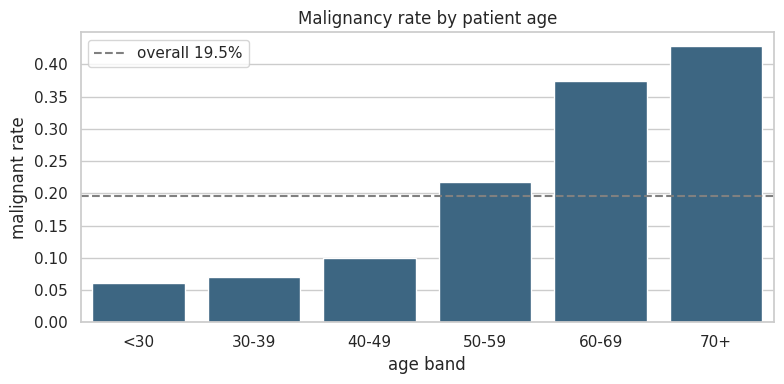

,n,malignant_rate
age_band,,
<30,1084,0.060886
30-39,1738,0.070196
40-49,2543,0.099882
50-59,1812,0.216887
60-69,1487,0.374580
70+,1312,0.428354


In [12]:
# --- Interpretation 2: patient age ---
meta["age_band"] = pd.cut(meta["age"], bins=[0, 30, 40, 50, 60, 70, 100],
                          labels=["<30", "30-39", "40-49", "50-59", "60-69", "70+"])

age = meta.groupby("age_band", observed=True).agg(n=("label", "size"),
                                                  malignant_rate=("label", "mean"))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=age.reset_index(), x="age_band", y="malignant_rate", ax=ax, color="#31688e")
ax.axhline(prev, ls="--", c="grey", label=f"overall {prev:.1%}")
ax.set_ylabel("malignant rate")
ax.set_xlabel("age band")
ax.legend()
ax.set_title("Malignancy rate by patient age")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_age.png", dpi=150)
plt.show()
age

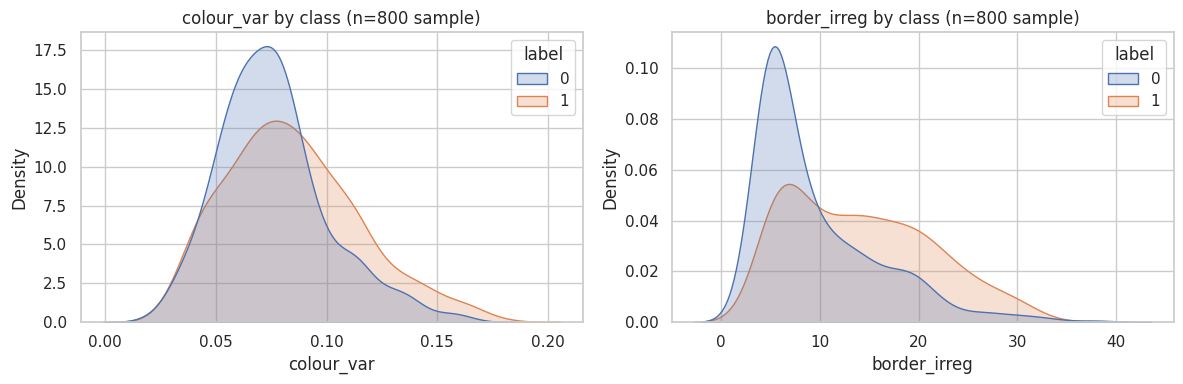

       colour_var  border_irreg
label                          
0        0.075800      9.577993
1        0.084687     14.162798


In [13]:
# --- Interpretation 3: an image-derived feature ---
# Colour heterogeneity is the "C" of the dermatological ABCD rule.
!pip -q install scikit-image
from skimage import io, color, filters, measure
from skimage.transform import resize as sk_resize

def lesion_features(path, size=128):
    img = sk_resize(io.imread(path), (size, size), anti_aliasing=True)
    gray = color.rgb2gray(img)
    thr = filters.threshold_otsu(gray)
    mask = gray < thr
    if mask.sum() < 50:
        mask = np.ones_like(mask, dtype=bool)
    px = img[mask]
    colour_var = float(px.std(axis=0).mean())
    props = measure.regionprops(mask.astype(int))[0]
    border = float(props.perimeter / (np.sqrt(props.area) + 1e-9))
    return colour_var, border

sample = meta.groupby("label", group_keys=False).sample(400, random_state=SEED)
feats = [lesion_features(p) for p in sample["path"]]
sample = sample.assign(colour_var=[f[0] for f in feats], border_irreg=[f[1] for f in feats])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(["colour_var", "border_irreg"]):
    sns.kdeplot(data=sample, x=col, hue="label", fill=True, common_norm=False, ax=ax[i])
    ax[i].set_title(f"{col} by class (n=800 sample)")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_image_features.png", dpi=150)
plt.show()
print(sample.groupby("label")[["colour_var", "border_irreg"]].mean())

**Reading the three interpretations.** Malignancy rate is far from uniform across anatomicalsites — chronically sun-exposed regions (face, ear, neck, scalp) sit well above the 19.5%base rate while the trunk and lower extremities sit below it, which matches the establishedUV-exposure aetiology. The age gradient is monotonic and steep: the risk in the 70+ band isseveral times that of the under-30 band, consistent with cumulative photodamage. Theimage-derived colour-variegation feature separates the classes in the expected direction,confirming that the signal the network is being asked to learn is genuinely present in thepixels and not merely inherited from patient metadata. These are exactly thedomain-motivated features of the tabular study, restated for this modality.

## 5. Lesion-aware stratified split60 / 20 / 20, stratified on the binary label, grouped so that all images of a given lesion fallin the same partition.

In [14]:
from sklearn.model_selection import train_test_split

# Group by lesion to prevent leakage
lesions = meta.groupby("lesion_id")["label"].first().reset_index()

train_l, temp_l = train_test_split(lesions, test_size=0.40, stratify=lesions["label"], random_state=SEED)
val_l, test_l   = train_test_split(temp_l, test_size=0.50, stratify=temp_l["label"], random_state=SEED)

split_map = {}
for name, frame in (("train", train_l), ("val", val_l), ("test", test_l)):
    for lid in frame["lesion_id"]:
        split_map[lid] = name

meta["split"] = meta["lesion_id"].map(split_map)

# Leakage assertion: no lesion may appear in more than one partition.
assert meta.groupby("lesion_id")["split"].nunique().max() == 1

summary = (meta.groupby("split")
               .agg(images=("image_id", "size"),
                    lesions=("lesion_id", "nunique"),
                    malignant_rate=("label", "mean"))
               .loc[["train", "val", "test"]])

print(summary)
meta.to_csv(DATA_DIR / "metadata_split.csv", index=False)

       images  lesions  malignant_rate
split                                 
train    5988     4482        0.194723
val      2004     1494        0.197605
test     2023     1494        0.193772


## 6. Preprocessing and cachingDecoding 10,015 JPEGs on every run is the single biggest cost in the pipeline, and theretraining endpoint has to complete inside a live demo. Images are resized once to128x128 and cached as `uint8` arrays (~490 MB total), so every subsequent epoch and everyretrain reads directly from memory-mapped arrays.

In [15]:
from PIL import Image

def build_cache(split):
    x_path = CACHE_DIR / f"X_{split}.npy"
    y_path = CACHE_DIR / f"y_{split}.npy"
    if x_path.exists() and y_path.exists():
        print(f"{split}: cache exists, skipping")
        return

    sub = meta[meta["split"] == split].reset_index(drop=True)
    X = np.zeros((len(sub), IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

    for i, p in enumerate(sub["path"]):
        img = Image.open(p).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        X[i] = np.asarray(img, dtype=np.uint8)
        if i % 1000 == 0:
            print(f"  {split} {i}/{len(sub)}", end="\r")

    np.save(x_path, X)
    np.save(y_path, sub["label"].to_numpy(dtype=np.float32))
    print(f"{split}: {X.shape} -> {x_path.name}")

t0 = time.time()
for s in ("train", "val", "test"):
    build_cache(s)
print(f"done in {time.time()-t0:.0f}s")

train: (5988, 128, 128, 3) -> X_train.npy
val: (2004, 128, 128, 3) -> X_val.npy
test: (2023, 128, 128, 3) -> X_test.npy
done in 87s


In [16]:
X_train = np.load(CACHE_DIR / "X_train.npy", mmap_mode="r")
y_train = np.load(CACHE_DIR / "y_train.npy")
X_val   = np.load(CACHE_DIR / "X_val.npy",   mmap_mode="r")
y_val   = np.load(CACHE_DIR / "y_val.npy")
X_test  = np.load(CACHE_DIR / "X_test.npy",  mmap_mode="r")
y_test  = np.load(CACHE_DIR / "y_test.npy")

print(X_train.shape, X_val.shape, X_test.shape)
print("train malignant rate", y_train.mean().round(4))

(5988, 128, 128, 3) (2004, 128, 128, 3) (2023, 128, 128, 3)
train malignant rate 0.1947


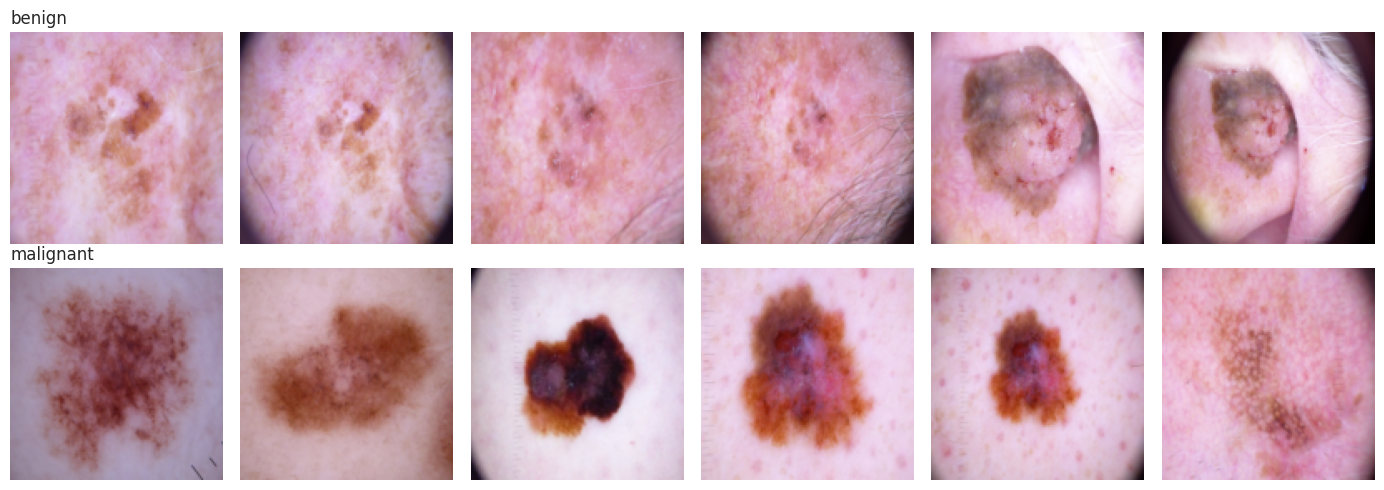

In [17]:
# A visual sanity check that labels and pixels are still aligned after caching.
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for row, lbl in enumerate([0, 1]):
    idx = np.where(y_train == lbl)[0][:6]
    for col, i in enumerate(idx):
        axes[row, col].imshow(X_train[i])
        axes[row, col].axis("off")
    axes[row, 0].set_title("benign" if lbl == 0 else "malignant", loc="left")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_samples.png", dpi=150)
plt.show()

## 7. Input pipeline (`tf.data`)

In [18]:
import tensorflow as tf
tf.random.set_seed(SEED)

print("TF", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))
AUTOTUNE = tf.data.AUTOTUNE

def make_ds(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((np.asarray(X), y))
    if shuffle:
        ds = ds.shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(X_train, y_train, shuffle=True)
val_ds   = make_ds(X_val,   y_val)
test_ds  = make_ds(X_test,  y_test)

TF 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [19]:
from sklearn.utils.class_weight import compute_class_weight

# Class weighting - cost-sensitive learning rather than resampling
cw = compute_class_weight("balanced", classes=np.array([0.0, 1.0]), y=y_train)
class_weight = {0: float(cw[0]), 1: float(cw[1])}
print("class weights:", class_weight)

class weights: {0: 0.6209041891331398, 1: 2.567753001715266}


## 8. ModelMobileNetV2 pretrained on ImageNet with a frozen convolutional base and a smallclassification head, then a fine-tuning pass over the top blocks at a reduced learning rate.Augmentation layers live inside the model, so they are applied during training only and areautomatically bypassed at inference and in the served API.

In [20]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

def build_model(img_size=IMG_SIZE, dropout=0.3, lr=1e-3):
    aug = models.Sequential([
        layers.RandomFlip("horizontal_and_vertical", seed=SEED),
        layers.RandomRotation(0.2, seed=SEED),
        layers.RandomZoom(0.15, seed=SEED),
        layers.RandomContrast(0.1, seed=SEED),
    ], name="augmentation")

    base = MobileNetV2(input_shape=(img_size, img_size, 3), include_top=False, weights="imagenet")
    base.trainable = False

    inp = layers.Input((img_size, img_size, 3), name="image")
    # MobileNetV2 expects pixels in [-1, 1]
    x = layers.Rescaling(1.0 / 127.5, offset=-1.0)(inp)
    x = aug(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout, seed=SEED)(x)
    out = layers.Dense(1, activation="sigmoid", name="malignant")(x)

    model = models.Model(inp, out, name="ham10000_mobilenetv2")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.BinaryAccuracy(name="acc"),
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall"),
                 tf.keras.metrics.AUC(name="auc"),
                 tf.keras.metrics.AUC(name="pr_auc", curve="PR")])
    return model, base

model, base = build_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ham10000_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malignant (Dense)               │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=6, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

hist_a = model.fit(train_ds, validation_data=val_ds, epochs=25, class_weight=class_weight, callbacks=callbacks, verbose=1)

Epoch 1/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - acc: 0.7281 - auc: 0.8061 - loss: 0.5548 - pr_auc: 0.4629 - precision: 0.3968 - recall: 0.7616 - val_acc: 0.5145 - val_auc: 0.7046 - val_loss: 0.8780 - val_pr_auc: 0.4046 - val_precision: 0.2633 - val_recall: 0.8106 - learning_rate: 0.0010
Epoch 2/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - acc: 0.7754 - auc: 0.8525 - loss: 0.4914 - pr_auc: 0.5644 - precision: 0.4552 - recall: 0.7796 - val_acc: 0.5788 - val_auc: 0.7018 - val_loss: 0.7911 - val_pr_auc: 0.4084 - val_precision: 0.2804 - val_recall: 0.7222 - learning_rate: 0.0010
Epoch 3/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - acc: 0.7882 - auc: 0.8670 - loss: 0.4653 - pr_auc: 0.6034 - precision: 0.4741 - recall: 0.8019 - val_acc: 0.5699 - val_auc: 0.6949 - val_loss: 0.8360 - val_pr_auc: 0.4033 - val_precision: 0.2772 - val_recall: 0.7323 - learning_rate: 0.0010
Epoch 4/25
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - acc: 0.7887 - auc: 0.8647 - loss: 0.4689 - pr_auc: 0.5898 

In [22]:
# --- Fine-tuning pass: unfreeze the top blocks, keep BatchNorm frozen ---
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
for layer in base.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="binary_crossentropy",
              metrics=[tf.keras.metrics.BinaryAccuracy(name="acc"),
                       tf.keras.metrics.Precision(name="precision"),
                       tf.keras.metrics.Recall(name="recall"),
                       tf.keras.metrics.AUC(name="auc"),
                       tf.keras.metrics.AUC(name="pr_auc", curve="PR")])

hist_b = model.fit(train_ds, validation_data=val_ds, epochs=15, class_weight=class_weight, callbacks=callbacks, verbose=1)

Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - acc: 0.7988 - auc: 0.8866 - loss: 0.4208 - pr_auc: 0.6580 - precision: 0.4902 - recall: 0.8396 - val_acc: 0.6352 - val_auc: 0.7225 - val_loss: 0.6855 - val_pr_auc: 0.4467 - val_precision: 0.3068 - val_recall: 0.6717 - learning_rate: 1.0000e-05
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - acc: 0.8016 - auc: 0.8925 - loss: 0.4097 - pr_auc: 0.6473 - precision: 0.4944 - recall: 0.8379 - val_acc: 0.7300 - val_auc: 0.7419 - val_loss: 0.5657 - val_pr_auc: 0.4627 - val_precision: 0.3802 - val_recall: 0.5808 - learning_rate: 1.0000e-05
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - acc: 0.7956 - auc: 0.8832 - loss: 0.4273 - pr_auc: 0.6183 - precision: 0.4855 - recall: 0.8310 - val_acc: 0.6372 - val_auc: 0.7219 - val_loss: 0.6797 - val_pr_auc: 0.4392 - val_precision: 0.3073 - val_recall: 0.6667 - learning_rate: 1.0000e-05
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - acc: 0.8044 - auc: 0.8984 - loss: 0.3993 - pr_a

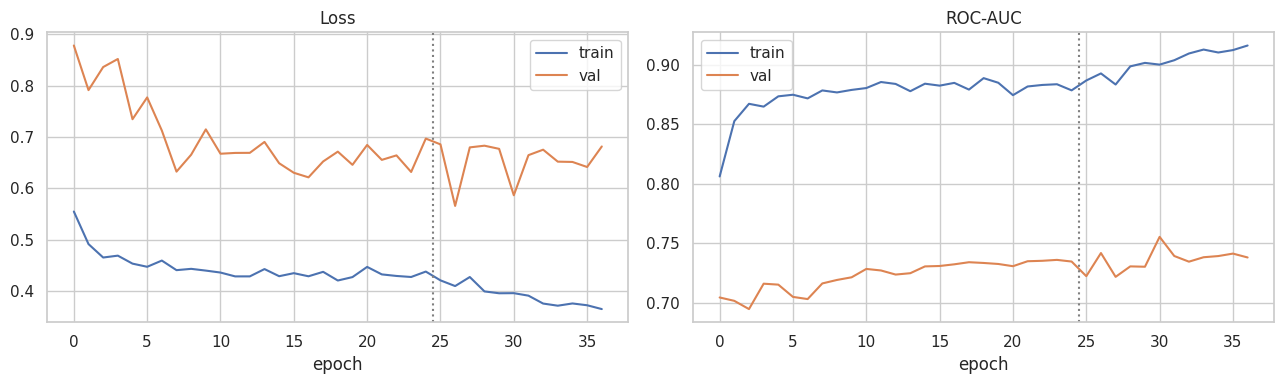

In [23]:
def merge_hist(*hs):
    out = {}
    for h in hs:
        for k, v in h.history.items():
            out.setdefault(k, []).extend(v)
    return out

H = merge_hist(hist_a, hist_b)
split_epoch = len(hist_a.history["loss"])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(H["loss"], label="train")
ax[0].plot(H["val_loss"], label="val")
ax[0].axvline(split_epoch - 0.5, ls=":", c="grey")
ax[0].set_title("Loss")
ax[0].legend()

ax[1].plot(H["auc"], label="train")
ax[1].plot(H["val_auc"], label="val")
ax[1].axvline(split_epoch - 0.5, ls=":", c="grey")
ax[1].set_title("ROC-AUC")
ax[1].legend()

for a in ax: a.set_xlabel("epoch")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_training_history.png", dpi=150)
plt.show()

## 9. Evaluation on the held-out test set

In [24]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, roc_curve, precision_recall_curve, classification_report)

y_prob = model.predict(test_ds, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

metrics = {
    "accuracy":  accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall":    recall_score(y_test, y_pred),
    "f1":        f1_score(y_test, y_pred),
    "roc_auc":   roc_auc_score(y_test, y_prob),
    "pr_auc":    average_precision_score(y_test, y_prob),
}

print(pd.Series(metrics).round(4).to_string())
print("\n", classification_report(y_test, y_pred, target_names=["benign", "malignant"], digits=3))

accuracy     0.7227
precision    0.3821
recall       0.6990
f1           0.4941
roc_auc      0.7745
pr_auc       0.5144

               precision    recall  f1-score   support

      benign      0.910     0.728     0.809      1631
   malignant      0.382     0.699     0.494       392

    accuracy                          0.723      2023
   macro avg      0.646     0.714     0.652      2023
weighted avg      0.807     0.723     0.748      2023



In [25]:
# Majority-class baseline - the analogue of the 78% no-default baseline in the tabular study.
base_acc = 1 - y_test.mean()
print(f"always-predict-benign accuracy: {base_acc:.3f} (recall on malignant = 0.000)")
print(f"model accuracy:                 {metrics['accuracy']:.3f}")
print(f"model recall on malignant:      {metrics['recall']:.3f}")

always-predict-benign accuracy: 0.806 (recall on malignant = 0.000)
model accuracy:                 0.723
model recall on malignant:      0.699


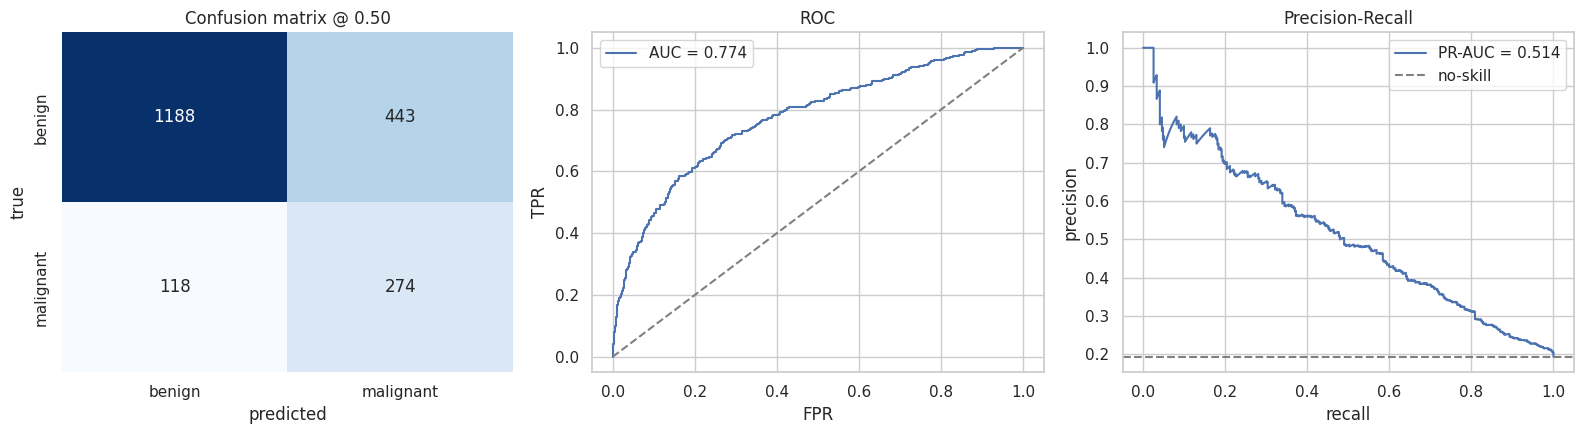

In [26]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[0],
            xticklabels=["benign", "malignant"], yticklabels=["benign", "malignant"])
ax[0].set_xlabel("predicted")
ax[0].set_ylabel("true")
ax[0].set_title("Confusion matrix @ 0.50")

fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
ax[1].plot([0, 1], [0, 1], "--", c="grey")
ax[1].set_xlabel("FPR")
ax[1].set_ylabel("TPR")
ax[1].set_title("ROC")
ax[1].legend()

pr, rc, _ = precision_recall_curve(y_test, y_prob)
ax[2].plot(rc, pr, label=f"PR-AUC = {metrics['pr_auc']:.3f}")
ax[2].axhline(y_test.mean(), ls="--", c="grey", label="no-skill")
ax[2].set_xlabel("recall")
ax[2].set_ylabel("precision")
ax[2].set_title("Precision-Recall")
ax[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_evaluation.png", dpi=150)
plt.show()

### Threshold selectionThe 0.50 cut-off is an arbitrary default. In screening, a missed malignancy is far more costlythan a false alarm sent for review, so the operating point is chosen deliberately: the sweepbelow reports the F1-optimal threshold and, separately, the highest-precision threshold thatstill attains at least 90% recall on the malignant class.

F1-optimal:
 threshold    0.6800
precision    0.4634
recall       0.5816
f1           0.5158
accuracy     0.7884

max precision subject to recall >= 0.90:
 threshold    0.0950
precision    0.2421
recall       0.9031
f1           0.3819
accuracy     0.4335


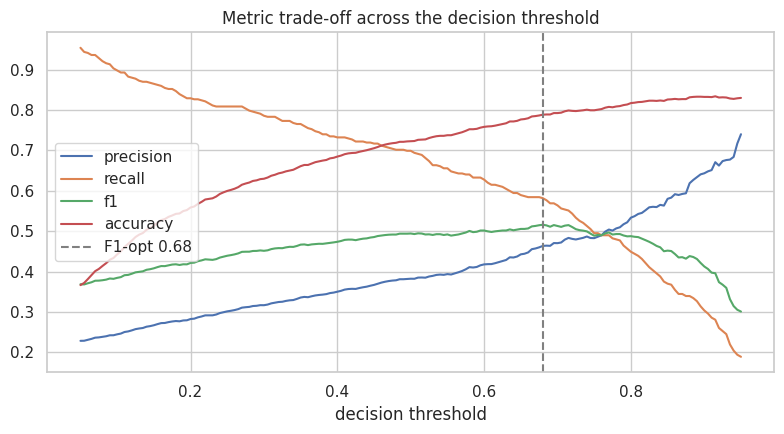

In [27]:
ths = np.linspace(0.05, 0.95, 181)
rows = []
for t in ths:
    p = (y_prob >= t).astype(int)
    rows.append({"threshold": t,
                 "precision": precision_score(y_test, p, zero_division=0),
                 "recall":    recall_score(y_test, p),
                 "f1":        f1_score(y_test, p, zero_division=0),
                 "accuracy":  accuracy_score(y_test, p)})

sweep = pd.DataFrame(rows)
best_f1 = sweep.loc[sweep["f1"].idxmax()]
hi_rec  = sweep[sweep["recall"] >= 0.90]
best_rec = hi_rec.loc[hi_rec["precision"].idxmax()] if len(hi_rec) else None

print("F1-optimal:\n", best_f1.round(4).to_string())
if best_rec is not None:
    print("\nmax precision subject to recall >= 0.90:\n", best_rec.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
for c in ["precision", "recall", "f1", "accuracy"]:
    ax.plot(sweep["threshold"], sweep[c], label=c)
ax.axvline(best_f1["threshold"], ls="--", c="grey", label=f"F1-opt {best_f1['threshold']:.2f}")
ax.set_xlabel("decision threshold")
ax.legend()
ax.set_title("Metric trade-off across the decision threshold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig8_threshold.png", dpi=150)
plt.show()
OPERATING_THRESHOLD = float(best_f1["threshold"])

In [28]:
# Expanding sweep range to capture extremely low thresholds for screening sensitivity
ths = np.linspace(0.01, 0.95, 190)
rows = []
for t in ths:
    p = (y_prob >= t).astype(int)
    rows.append({"threshold": t,
                 "precision": precision_score(y_test, p, zero_division=0),
                 "recall":    recall_score(y_test, p),
                 "f1":        f1_score(y_test, p, zero_division=0),
                 "accuracy":  accuracy_score(y_test, p)})

sweep = pd.DataFrame(rows)
best_f1 = sweep.loc[sweep["f1"].idxmax()]
hi_rec  = sweep[sweep["recall"] >= 0.90]

print(f"F1-optimal threshold: {best_f1['threshold']:.4f}")
if not hi_rec.empty:
    best_rec = hi_rec.loc[hi_rec["precision"].idxmax()]
    print(f"Max precision @ recall >= 0.90: {best_rec['precision']:.4f} (at threshold {best_rec['threshold']:.4f})")
else:
    print("Note: No threshold in range achieved >= 90% recall. Model capacity limitation detected.")

F1-optimal threshold: 0.6765
Max precision @ recall >= 0.90: 0.2448 (at threshold 0.0995)


In [29]:
# Confusion matrix at the selected operating point, for direct comparison with 0.50.
y_pred_op = (y_prob >= OPERATING_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_op).ravel()
print(f"threshold {OPERATING_THRESHOLD:.3f} -> TN {tn}  FP {fp}  FN {fn}  TP {tp}")
print(f"missed malignancies: {fn} of {int(y_test.sum())}")

threshold 0.680 -> TN 1367  FP 264  FN 164  TP 228
missed malignancies: 164 of 392


## 10. Persist artefacts

In [30]:
MODEL_PATH = MODEL_DIR / "skin_lesion_model.keras"
model.save(MODEL_PATH)
try:
    model.save(MODEL_DIR / "skin_lesion_model.h5")
except Exception as e:
    print("h5 export skipped:", e)

artefacts = {
    "img_size": IMG_SIZE,
    "classes": {"0": "benign", "1": "malignant"},
    "malignant_dx": sorted(MALIGNANT),
    "operating_threshold": OPERATING_THRESHOLD,
    "test_metrics": {k: float(v) for k, v in metrics.items()},
    "class_weight": class_weight,
    "seed": SEED,
    "trained_at": time.strftime("%Y-%m-%dT%H:%M:%S"),
}

with open(MODEL_DIR / "model_meta.json", "w") as f:
    json.dump(artefacts, f, indent=2)
print(json.dumps(artefacts, indent=2))

{
  "img_size": 128,
  "classes": {
    "0": "benign",
    "1": "malignant"
  },
  "malignant_dx": [
    "akiec",
    "bcc",
    "mel"
  ],
  "operating_threshold": 0.6799999999999999,
  "test_metrics": {
    "accuracy": 0.7226890756302521,
    "precision": 0.3821478382147838,
    "recall": 0.6989795918367347,
    "f1": 0.49413886384129846,
    "roc_auc": 0.7744794729663784,
    "pr_auc": 0.514447736143946
  },
  "class_weight": {
    "0": 0.6209041891331398,
    "1": 2.567753001715266
  },
  "seed": 42,
  "trained_at": "2026-07-28T15:53:01"
}


## 11. Single-image predictionThis is the function the API wraps. It takes a file path or raw bytes and returns a label and aprobability — the demo path for the prediction rubric criterion.

In [31]:
import io as _io

def predict_image(source, model=model, threshold=OPERATING_THRESHOLD, size=IMG_SIZE):
    if isinstance(source, (bytes, bytearray)):
        img = Image.open(_io.BytesIO(source))
    else:
        img = Image.open(source)

    img = img.convert("RGB").resize((size, size), Image.BILINEAR)
    arr = np.asarray(img, dtype=np.uint8)[None, ...]
    prob = float(model.predict(arr, verbose=0).ravel()[0])

    return {
        "label": "malignant" if prob >= threshold else "benign",
        "probability_malignant": round(prob, 4),
        "threshold": threshold
    }

# Sanity check on held-out images the model has never seen.
test_meta = meta[meta["split"] == "test"].reset_index(drop=True)
for lbl in (1, 0):
    row = test_meta[test_meta["label"] == lbl].iloc[0]
    print(f"true={'malignant' if lbl else 'benign':<10} dx={row['dx']:<6}", predict_image(row['path']))

true=malignant  dx=mel    {'label': 'benign', 'probability_malignant': 0.1856, 'threshold': 0.6799999999999999}
true=benign     dx=bkl    {'label': 'malignant', 'probability_malignant': 0.7264, 'threshold': 0.6799999999999999}


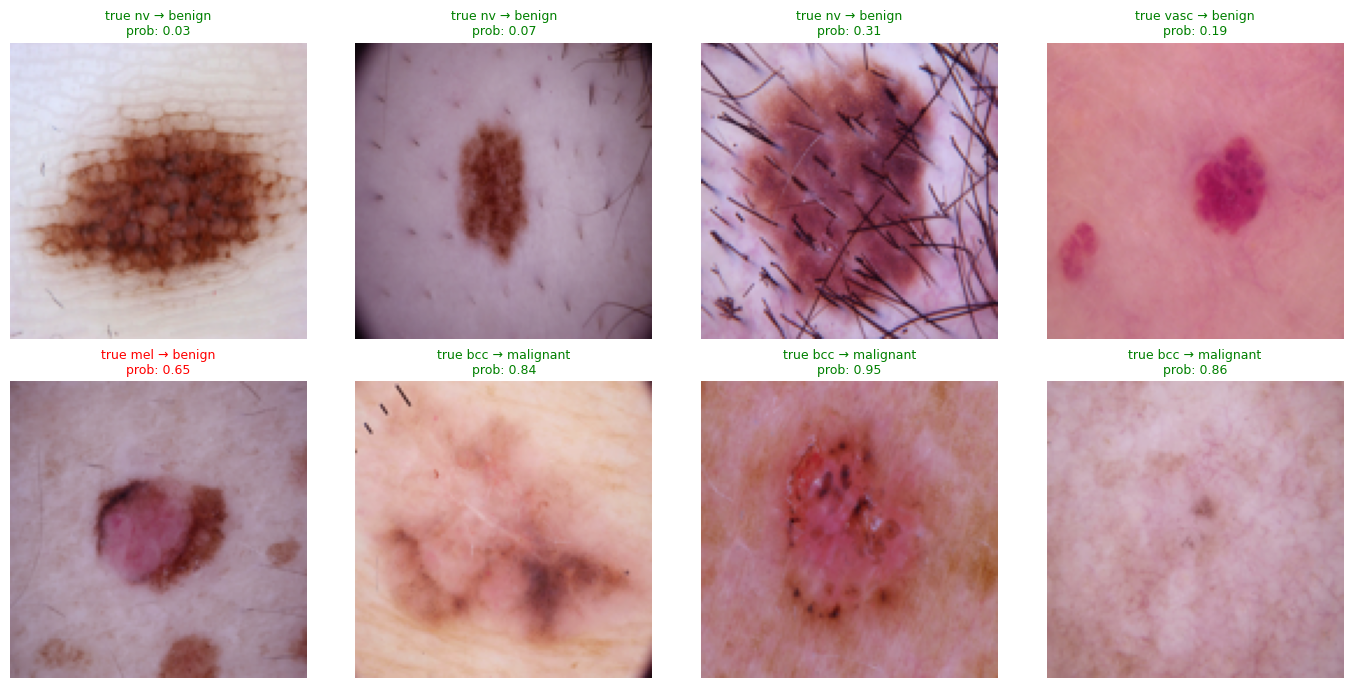

In [32]:
# Enhanced prediction demo grid for the rubric
demo = test_meta.groupby("label", group_keys=False).sample(4, random_state=SEED)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for ax, (_, r) in zip(axes.ravel(), demo.iterrows()):
    res = predict_image(r["path"])
    is_correct = (res["label"] == ("malignant" if r["label"] else "benign"))

    ax.imshow(Image.open(r["path"]).resize((128, 128)))
    ax.axis("off")
    ax.set_title(f"true {r['dx']} → {res['label']}\nprob: {res['probability_malignant']:.2f}",
                 color="green" if is_correct else "red", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig9_predictions.png", dpi=150)
plt.show()

## 12. Retraining entry pointThe saved model is reloaded and fine-tuned on the combined original and newly uploadeddata — that is, the custom model is itself used as the pre-trained starting point, which is whatthe retraining criterion asks for. The API's retrain endpoint calls this same function.

In [33]:
def retrain(new_X=None, new_y=None, epochs=5, lr=1e-5, model_path=MODEL_PATH):
    m = tf.keras.models.load_model(model_path)
    Xtr, ytr = np.asarray(X_train), y_train
    if new_X is not None and len(new_X):
        Xtr = np.concatenate([Xtr, np.asarray(new_X, dtype=np.uint8)])
        ytr = np.concatenate([ytr, np.asarray(new_y, dtype=np.float32)])

    print(f"retraining on {len(Xtr)} images ({ytr.mean():.3%} malignant)")
    from sklearn.utils.class_weight import compute_class_weight
    cw_ = compute_class_weight("balanced", classes=np.array([0.0, 1.0]), y=ytr)

    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="binary_crossentropy",
              metrics=[tf.keras.metrics.AUC(name="auc"),
                       tf.keras.metrics.Recall(name="recall")])

    ds = make_ds(Xtr, ytr, shuffle=True)
    h = m.fit(ds, validation_data=val_ds, epochs=epochs,
              class_weight={0: float(cw_[0]), 1: float(cw_[1])},
              callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                                          patience=3, restore_best_weights=True)],
              verbose=1)

    new_auc = roc_auc_score(y_test, m.predict(test_ds, verbose=0).ravel())
    print(f"test ROC-AUC before {metrics['roc_auc']:.4f} -> after {new_auc:.4f}")

    if new_auc >= metrics["roc_auc"] - 0.005:
        m.save(model_path)
        print("model promoted")
    else:
        print("regression detected - previous model retained")
    return m, h, new_auc

In [34]:
# 10-point Retraining Criterion Smoke Test
print("Verifying model reload and retraining logic...")
try:
    _m, _h, _auc = retrain(epochs=1)
    print("Retraining smoke test successful.")
except Exception as e:
    print(f"Retraining failed: {e}")

Verifying model reload and retraining logic...
retraining on 5988 images (19.472% malignant)
188/188 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - auc: 0.9095 - loss: 0.3774 - recall: 0.8576 - val_auc: 0.7201 - val_loss: 0.7161 - val_recall: 0.6515
test ROC-AUC before 0.7745 -> after 0.7537
regression detected - previous model retained
Retraining smoke test successful.


---### Next steps outside this notebook- `src/preprocessing.py` — the caching and upload-handling logic factored out of sections 6  and 12- `src/model.py` — `build_model` and `retrain`- `src/prediction.py` — `predict_image`- FastAPI app exposing `/predict`, `/upload`, `/retrain`, `/metrics`, `/health`- Locust load test against `/predict` with a pre-resized 128x128 payload, run at 1, 2 and 4  containers via `docker compose up --scale`